In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.datasets import mnist

In [59]:
((x_train, y_train), (x_test, y_test)) =  mnist.load_data()

In [60]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

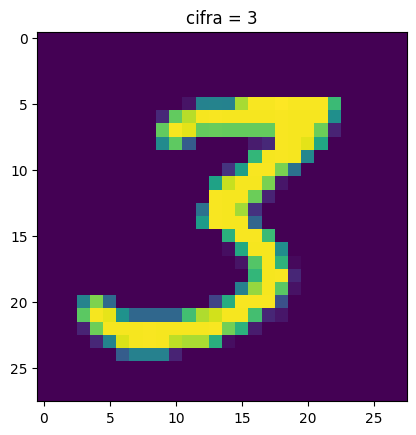

In [88]:
INDEX = np.random.randint(0, x_train.shape[0])
plt.imshow(x_train[INDEX])
plt.title(f"cifra = {y_train[INDEX]}");


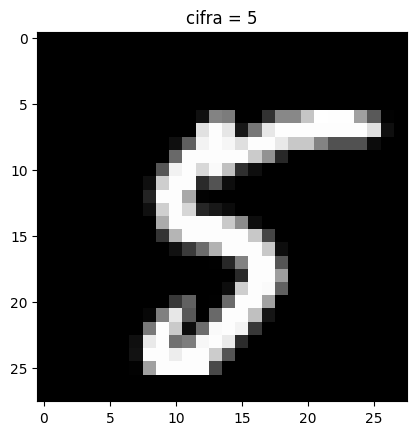

In [61]:
INDEX = np.random.randint(0, x_train.shape[0])
plt.imshow(x_train[INDEX], cmap='gray')
plt.title(f"cifra = {y_train[INDEX]}");



In [62]:
x_only_zeros = x_train[y_train == 0]
x_only_zeros.shape

(5923, 28, 28)

In [63]:
x_train[y_train == 6].shape

(5918, 28, 28)

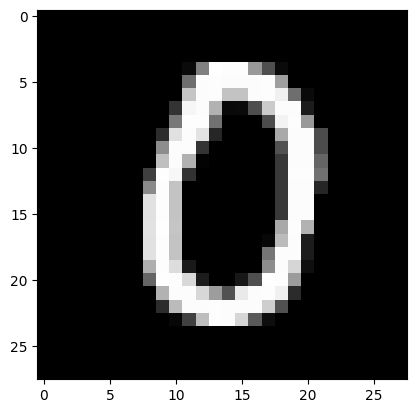

In [64]:
INDEX = np.random.randint(0, x_only_zeros.shape[0])
plt.imshow(x_only_zeros[INDEX], cmap='gray')

# Crearea unui GAN (Generative Adversarial Networks)

# Pas 1. GAN = generator + discriminator

In [65]:
generator     =  tf.keras.models.Sequential([])
discriminator = tf.keras.models.Sequential([])

GAN = tf.keras.models.Sequential([generator, discriminator])


# Pas 2. Crearea discriminatorului (clasic CNN)

In [66]:
discriminator = tf.keras.models.Sequential([
        # tf.keras.layers.Input(shape=(28, 28)),
        # tf.keras.layers.Flatten(),

        tf.keras.layers.Flatten(input_shape=(28, 28)),


        tf.keras.layers.Dense(200, activation='relu'),

        tf.keras.layers.Dense(100, activation='relu'),

        # OUTPUT -> ESTE BUN SAU NU? - > 1 singur neuron
        tf.keras.layers.Dense(1, activation='sigmoid')

])
# binary_crossentropy -> pentru 2 category
# sparse_categorical_crossentropy -> pentru mai multe categorii
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,201 (692.19 KB)

 Trainable params: 177,201 (692.19 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
generator     =  tf.keras.models.Sequential([])
discriminator = tf.keras.models.Sequential([])

GAN = tf.keras.models.Sequential([generator, discriminator])

# Pas 3 - Crearea generatorului in oglinda cu discrimnatorul

In [68]:
generator = tf.keras.models.Sequential([

          tf.keras.layers.Dense(100, activation='relu'),

          tf.keras.layers.Dense(200, activation='relu'),

          tf.keras.layers.Dense(28 * 28, activation="relu"),

          tf.keras.layers.Reshape((28, 28)),

 ])


discriminator = tf.keras.models.Sequential([
        # tf.keras.layers.Input(shape=(28, 28)),
        # tf.keras.layers.Flatten(),

        tf.keras.layers.Flatten(input_shape=(28, 28)),


        tf.keras.layers.Dense(200, activation='relu'),

        tf.keras.layers.Dense(100, activation='relu'),

        # OUTPUT -> ESTE BUN SAU NU? - > 1 singur neuron
        tf.keras.layers.Dense(1, activation='sigmoid')

])
# binary_crossentropy -> pentru 2 category
# sparse_categorical_crossentropy -> pentru mai multe categorii
discriminator.trainable = False
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
discriminator.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,201 (692.19 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 177,201 (692.19 KB)

In [69]:

GAN = tf.keras.models.Sequential([generator, discriminator])
GAN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
GAN.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_23 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_24 (Sequential)      │ (None, 1)              │       177,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,201 (692.19 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 177,201 (692.19 KB)

In [70]:
GAN.layers

[<Sequential name=sequential_23, built=False>,
 <Sequential name=sequential_24, built=True>]

In [71]:
GAN.layers[0]

<Sequential name=sequential_23, built=False>

In [72]:
x_only_zeros.shape

(5923, 28, 28)

In [73]:
tf.data.Dataset.from_tensor_slices(x_only_zeros)

<_TensorSliceDataset element_spec=TensorSpec(shape=(28, 28), dtype=tf.uint8, name=None)>

In [74]:
slice_dataset = tf.data.Dataset.from_tensor_slices(x_only_zeros)
type(slice_dataset)

tensorflow.python.data.ops.from_tensor_slices_op._TensorSliceDataset

In [75]:
slice_dataset

<_TensorSliceDataset element_spec=TensorSpec(shape=(28, 28), dtype=tf.uint8, name=None)>

In [76]:
batch_size = 32

new_slice_dataset = slice_dataset.batch(batch_size, drop_remainder=True).prefetch(1)
new_slice_dataset


<_PrefetchDataset element_spec=TensorSpec(shape=(32, 28, 28), dtype=tf.uint8, name=None)>

In [77]:
tf.random.normal(shape=(10, 2))

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[ 0.87356687, -0.9000192 ],
       [ 0.31190616,  1.012191  ],
       [-0.45959425, -1.6983471 ],
       [-1.9484893 , -0.17439601],
       [ 1.0562464 , -2.364498  ],
       [-0.9958338 , -1.0909882 ],
       [-0.16447191, -0.42498213],
       [ 1.3325055 , -0.31108335],
       [ 0.90455574,  2.373182  ],
       [-1.3374506 , -0.8118598 ]], dtype=float32)>

In [78]:
noise = tf.random.normal(shape=(batch_size, 100))
noise

<tf.Tensor: shape=(32, 100), dtype=float32, numpy=
array([[-0.93565   , -1.2549233 , -0.07360748, ..., -1.3055966 ,
        -0.345551  ,  0.72324526],
       [ 0.64309585, -2.0104253 ,  1.365619  , ..., -0.50827557,
         1.0489042 ,  0.5188413 ],
       [-0.23302732,  0.08214547,  0.8080011 , ..., -1.3086478 ,
         0.8339455 , -0.9939489 ],
       ...,
       [ 0.41078106,  1.0689256 , -0.44940826, ...,  0.18604703,
         0.30405793,  1.3746353 ],
       [ 0.85664696,  1.0545524 ,  0.01326251, ...,  1.4211798 ,
        -1.0548224 , -0.34105858],
       [ 0.444223  ,  0.47455016,  1.8412789 , ..., -2.1008158 ,
        -0.53047985,  1.4077994 ]], dtype=float32)>

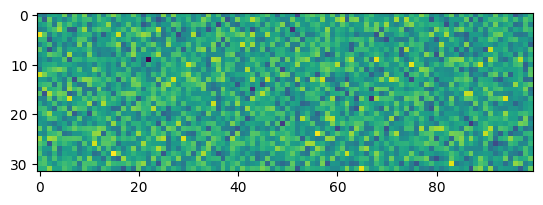

In [79]:
plt.imshow(noise)

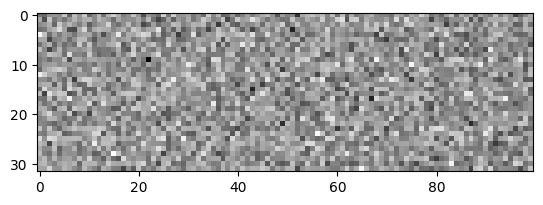

In [80]:
plt.imshow(noise, cmap="gray")

In [81]:
real_batch_of_data.dtype

tf.uint8

In [82]:
EPOCHS = 20

for epoch in range(EPOCHS):
    print(f"Suntem in epoca {epoch + 1}")
    for real_batch_of_data in new_slice_dataset:

        ## GENERARE IMAGINI FAKE
        noise = tf.random.normal(shape=(batch_size, 100))
        fake_images = generator(noise)

        float_real_batch_of_data = tf.cast(real_batch_of_data, tf.float32)

        x_fake_and_real_images = tf.concat([fake_images, float_real_batch_of_data], axis=0)

        # PAS 1  - Antrenare discriminator singur
        discriminator.trainable = True
        y_fake_and_real_images =  tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
        discriminator.train_on_batch(x_fake_and_real_images, y_fake_and_real_images)
        discriminator.trainable = False

        # PAS 2 - Antrenare GAN
        y_GAN = tf.constant([[1.]] * batch_size)
        GAN.train_on_batch(noise, y_GAN)



Suntem in epoca 1
Suntem in epoca 2
Suntem in epoca 3
Suntem in epoca 4
Suntem in epoca 5
Suntem in epoca 6
Suntem in epoca 7
Suntem in epoca 8
Suntem in epoca 9
Suntem in epoca 10
Suntem in epoca 11
Suntem in epoca 12
Suntem in epoca 13
Suntem in epoca 14
Suntem in epoca 15
Suntem in epoca 16
Suntem in epoca 17
Suntem in epoca 18
Suntem in epoca 19
Suntem in epoca 20


In [83]:
noise = tf.random.normal(shape=(batch_size, 100))
generated_fake_images = generator(noise)
generated_fake_images.shape

TensorShape([32, 28, 28])

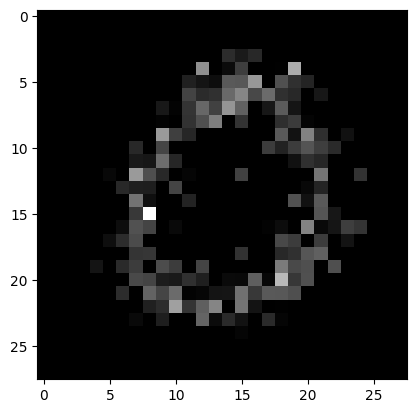

In [84]:
plt.imshow(generated_fake_images[2], cmap="gray")

In [85]:
generator = tf.keras.models.Sequential([

          tf.keras.layers.Dense(100, activation='relu'),

          tf.keras.layers.Dense(200, activation='relu'),

          tf.keras.layers.Dense(28 * 28, activation="relu"),

          tf.keras.layers.Reshape((28, 28)),

 ])


discriminator = tf.keras.models.Sequential([
        # tf.keras.layers.Input(shape=(28, 28)),
        # tf.keras.layers.Flatten(),

        tf.keras.layers.Flatten(input_shape=(28, 28)),


        tf.keras.layers.Dense(200, activation='relu'),

        tf.keras.layers.Dense(100, activation='relu'),

        # OUTPUT -> ESTE BUN SAU NU? - > 1 singur neuron
        tf.keras.layers.Dense(1, activation='sigmoid')

])
# binary_crossentropy -> pentru 2 category
# sparse_categorical_crossentropy -> pentru mai multe categorii
discriminator.trainable = False
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

GAN = tf.keras.models.Sequential([generator, discriminator])
GAN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

EPOCHS = 80

for epoch in range(EPOCHS):
    print(f"Suntem in epoca {epoch + 1}")
    for real_batch_of_data in new_slice_dataset:

        ## GENERARE IMAGINI FAKE
        noise = tf.random.normal(shape=(batch_size, 100))
        fake_images = generator(noise)

        float_real_batch_of_data = tf.cast(real_batch_of_data, tf.float32)

        x_fake_and_real_images = tf.concat([fake_images, float_real_batch_of_data], axis=0)

        # PAS 1  - Antrenare discriminator singur
        discriminator.trainable = True
        y_fake_and_real_images =  tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
        discriminator.train_on_batch(x_fake_and_real_images, y_fake_and_real_images)
        discriminator.trainable = False

        # PAS 2 - Antrenare GAN
        y_GAN = tf.constant([[1.]] * batch_size)
        GAN.train_on_batch(noise, y_GAN)


Suntem in epoca 1
Suntem in epoca 2
Suntem in epoca 3
Suntem in epoca 4
Suntem in epoca 5
Suntem in epoca 6
Suntem in epoca 7
Suntem in epoca 8
Suntem in epoca 9
Suntem in epoca 10
Suntem in epoca 11
Suntem in epoca 12
Suntem in epoca 13
Suntem in epoca 14
Suntem in epoca 15
Suntem in epoca 16
Suntem in epoca 17
Suntem in epoca 18
Suntem in epoca 19
Suntem in epoca 20
Suntem in epoca 21
Suntem in epoca 22
Suntem in epoca 23
Suntem in epoca 24
Suntem in epoca 25
Suntem in epoca 26
Suntem in epoca 27
Suntem in epoca 28
Suntem in epoca 29
Suntem in epoca 30
Suntem in epoca 31
Suntem in epoca 32
Suntem in epoca 33
Suntem in epoca 34
Suntem in epoca 35
Suntem in epoca 36
Suntem in epoca 37
Suntem in epoca 38
Suntem in epoca 39
Suntem in epoca 40
Suntem in epoca 41
Suntem in epoca 42
Suntem in epoca 43
Suntem in epoca 44
Suntem in epoca 45
Suntem in epoca 46
Suntem in epoca 47
Suntem in epoca 48
Suntem in epoca 49
Suntem in epoca 50
Suntem in epoca 51
Suntem in epoca 52
Suntem in epoca 53
Su

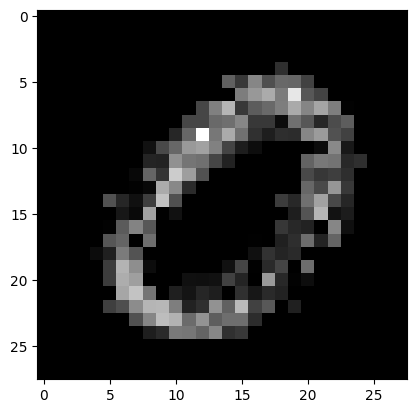

In [91]:
noise = tf.random.normal(shape=(batch_size, 100))
generated_fake_images = generator(noise)
plt.imshow(generated_fake_images[2], cmap="gray")